# Proyecto 2 - Modelo predictivo Saber 11 Atlántico

**Estudiante:** Isabella Caputi (202122075)


**Rol:** Ciencia de datos


**Usuario final:** Secretaría de Educación del Atlántico


## Pregunta de negocio


**¿Es posible predecir si un estudiante del Atlántico, a partir de las características institucionales de su colegio, alcanzará un puntaje global alto en las pruebas Saber 11?**


Este notebook desarrolla un modelo de clasificación binaria basado en redes neuronales para predecir si un estudiante alcanza un desempeño alto en Saber 11, usando únicamente variables institucionales del colegio.

---
## 1. Importar librerias

In [54]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)
from sklearn.linear_model import LogisticRegression

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

try:
    import mlflow
    import mlflow.keras
    MLFLOW_AVAILABLE = True
except ImportError:
    MLFLOW_AVAILABLE = False
    print("MLflow no está instalado. El modelo funcionará, pero no se registrarán experimentos.")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

pd.set_option("display.max_columns", None)

---

## 2. Cargar datos

En esta sección se cargan los datos limpios exportados del proceso de limpieza.

In [55]:
# Cargar librerías principales
import pandas as pd
import numpy as np

# Cargar datos limpios
ruta = '../Tarea 2 - Limpieza_Datos/saber11_limpio.csv'
df = pd.read_csv(ruta)
df.head()

,periodo,estu_tipodocumento,estu_consecutivo,cole_cod_dane_establecimiento,cole_cod_dane_sede,cole_cod_depto_ubicacion,cole_cod_mcpio_ubicacion,cole_codigo_icfes,cole_depto_ubicacion,cole_mcpio_ubicacion,cole_nombre_establecimiento,cole_nombre_sede,cole_sede_principal,estu_cod_depto_presentacion,estu_cod_mcpio_presentacion,estu_cod_reside_depto,estu_cod_reside_mcpio,estu_depto_presentacion,estu_depto_reside,estu_estadoinvestigacion,estu_estudiante,estu_fechanacimiento,estu_genero,estu_mcpio_presentacion,estu_mcpio_reside,estu_nacionalidad,estu_pais_reside,estu_privado_libertad,fami_cuartoshogar,fami_educacionmadre,fami_educacionpadre,fami_estratovivienda,fami_personashogar,fami_tieneautomovil,fami_tienecomputador,fami_tieneinternet,fami_tienelavadora,desemp_ingles,punt_ingles,punt_matematicas,punt_sociales_ciudadanas,punt_c_naturales,punt_lectura_critica,punt_global,cole_naturaleza_no oficial,cole_naturaleza_oficial,cole_bilingue_n,cole_bilingue_s,cole_jornada_completa,cole_jornada_mañana,cole_jornada_noche,cole_jornada_sabatina,cole_jornada_tarde,cole_jornada_unica,cole_calendario_a,cole_calendario_b,cole_calendario_otro,cole_area_ubicacion_rural,cole_area_ubicacion_urbano,cole_caracter_académico,cole_caracter_no aplica,cole_caracter_técnico,cole_caracter_técnico/académico,cole_genero_femenino,cole_genero_masculino,cole_genero_mixto,fami_estratovivienda_estrato 1,fami_estratovivienda_estrato 2,fami_estratovivienda_estrato 3,fami_estratovivienda_estrato 4,fami_estratovivienda_estrato 5,fami_estratovivienda_estrato 6,fami_estratovivienda_sin_informacion,fami_educacionmadre_educacion profesional completa,fami_educacionmadre_educacion profesional incompleta,fami_educacionmadre_ninguno,fami_educacionmadre_no aplica,fami_educacionmadre_no sabe,fami_educacionmadre_postgrado,fami_educacionmadre_primaria completa,fami_educacionmadre_primaria incompleta,fami_educacionmadre_secundaria (bachillerato) completa,fami_educacionmadre_secundaria (bachillerato) incompleta,fami_educacionmadre_sin_informacion,fami_educacionmadre_tecnica o tecnologica completa,fami_educacionmadre_tecnica o tecnologica incompleta,fami_educacionpadre_educacion profesional completa,fami_educacionpadre_educacion profesional incompleta,fami_educacionpadre_ninguno,fami_educacionpadre_no aplica,fami_educacionpadre_no sabe,fami_educacionpadre_postgrado,fami_educacionpadre_primaria completa,fami_educacionpadre_primaria incompleta,fami_educacionpadre_secundaria (bachillerato) completa,fami_educacionpadre_secundaria (bachillerato) incompleta,fami_educacionpadre_sin_informacion,fami_educacionpadre_tecnica o tecnologica completa,fami_educacionpadre_tecnica o tecnologica incompleta,fami_personashogar_1 a 2,fami_personashogar_3 a 4,fami_personashogar_5 a 6,fami_personashogar_7 a 8,fami_personashogar_9 o mas,fami_personashogar_sin_informacion,fami_cuartoshogar_cinco_o_mas,fami_cuartoshogar_cuatro,fami_cuartoshogar_dos,fami_cuartoshogar_sin_informacion,fami_cuartoshogar_tres,fami_cuartoshogar_uno,fami_tieneautomovil_no,fami_tieneautomovil_si,fami_tieneautomovil_sin_informacion,fami_tienelavadora_no,fami_tienelavadora_si,fami_tienelavadora_sin_informacion
0,20194,CC,SB11201940603865,3.080010e+11,3.080010e+11,8.0,8001.0,107227.0,ATLANTICO,BARRANQUILLA,CENTRO EDUCATIVO AURES,CENT EDUC AURES,S,8.0,8433.0,8.0,8001.0,ATLANTICO,ATLANTICO,PUBLICAR,ESTUDIANTE,09/09/1992,F,MALAMBO,BARRANQUILLA,COLOMBIA,COLOMBIA,N,dos,primaria incompleta,primaria incompleta,1.0,3 a 4,no,No,Si,si,A1,51.0,57.0,62.0,47.0,65.0,286.0,1,0,1,0,0,1,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0
1,20194,CC,SB11201940603865,3.080010e+11,3.080010e+11,8.0,8001.0,107227.0,ATLANTICO,BARRANQUILLA,CENTRO EDUCATIVO AURES,CENT EDUC AURES,S,8.0,8433.0,8.0,8001.0,ATLANTICO,ATLANTICO,PUBLICAR,ESTUDIANTE,09/09/1992,F,MALAMBO,BARRANQUILLA,COLOMBIA,COLOMBIA,N,dos,primaria incompleta,primaria incompleta,1.0,3 a 4,no,No,Si,si,A1,51.0,57.0,62.0,47.0

---
## 3. Análisis exploratorio y validación de datos

Antes de definir la variable objetivo, se realiza una exploración general de la base de datos, enfocada en:
- Dimensiones y duplicados
- Completitud y tipos de datos
- Estadísticas y validez de la variable objetivo
- Distribución y correlación de variables institucionales

Esto permite entender la calidad y estructura de los datos para tomar mejores decisiones de modelado.

(210695, 117)

Columnas: 117
Duplicados: 52019

Variables con valores faltantes:


fami_estratovivienda    12080
fami_tieneinternet       7773
fami_tienecomputador     5339
estu_genero               137
dtype: int64


Tipos de datos:


int64      74
object     27
float64    16
Name: count, dtype: int64


Estadísticas punt_global:


count    210695.000000
mean        249.635990
std          51.735807
min           0.000000
25%         210.000000
50%         245.000000
75%         285.000000
max         483.000000
Name: punt_global, dtype: float64

Valores fuera de rango (0-500): 0


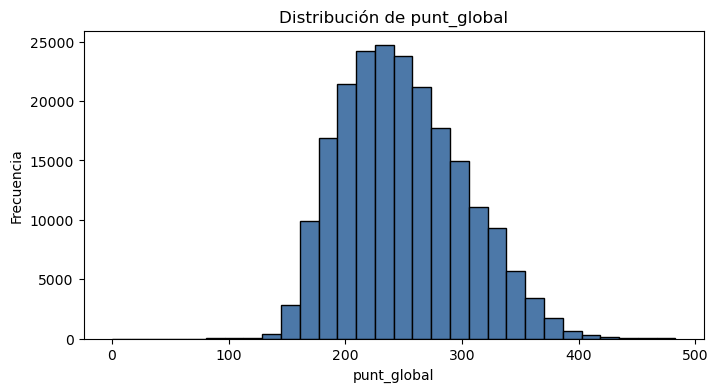


Correlación de variables COLE codificadas con punt_global:


cole_jornada_completa              0.349158
cole_jornada_noche                -0.279505
cole_calendario_b                  0.227701
cole_calendario_a                 -0.227403
cole_naturaleza_oficial           -0.207747
cole_naturaleza_no oficial         0.207747
cole_bilingue_s                    0.206401
cole_bilingue_n                   -0.206401
cole_genero_femenino               0.182544
cole_area_ubicacion_urbano         0.100461
cole_area_ubicacion_rural         -0.100461
cole_caracter_no aplica           -0.068775
cole_jornada_sabatina             -0.061639
cole_jornada_mañana               -0.059583
cole_caracter_técnico             -0.040941
cole_jornada_tarde                -0.035824
cole_caracter_académico            0.029001
cole_caracter_técnico/académico    0.021335
cole_jornada_unica                 0.016990
cole_calendario_otro               0.003207
dtype: float64

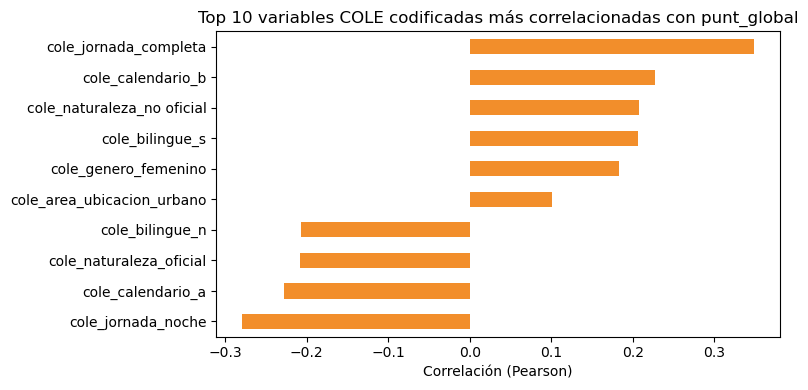

In [56]:
# Análisis exploratorio y validación de variables institucionales (COLE)
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Dimensiones y duplicados
display(df.shape)
print(f"Columnas: {df.shape[1]}")
print(f"Duplicados: {df.duplicated().sum()}")

# 2. Completitud y tipos de datos
faltantes = df.isna().sum()
if faltantes.sum() > 0:
    print("\nVariables con valores faltantes:")
    display(faltantes[faltantes > 0].sort_values(ascending=False))
else:
    print("No hay valores faltantes.")

print("\nTipos de datos:")
display(df.dtypes.value_counts())

# 3. Estadísticas y validez de la variable objetivo
if "punt_global" in df.columns:
    print("\nEstadísticas punt_global:")
    display(df["punt_global"].describe())
    print("Valores fuera de rango (0-500):", ((df["punt_global"] < 0) | (df["punt_global"] > 500)).sum())
    plt.figure(figsize=(8, 4))
    plt.hist(df["punt_global"].dropna(), bins=30, color="#4C78A8", edgecolor="black")
    plt.title("Distribución de punt_global")
    plt.xlabel("punt_global")
    plt.ylabel("Frecuencia")
    plt.show()

# 4. Análisis descriptivo y correlación de variables COLE codificadas con punt_global
# Si ya están dummies, seleccionarlas directamente
columnas_dummies_cole = [
    'cole_naturaleza_no oficial', 'cole_naturaleza_oficial',
    'cole_bilingue_n', 'cole_bilingue_s',
    'cole_jornada_completa', 'cole_jornada_mañana', 'cole_jornada_noche', 'cole_jornada_sabatina', 'cole_jornada_tarde', 'cole_jornada_unica',
    'cole_calendario_a', 'cole_calendario_b', 'cole_calendario_otro',
    'cole_area_ubicacion_rural', 'cole_area_ubicacion_urbano',
    'cole_caracter_académico', 'cole_caracter_no aplica', 'cole_caracter_técnico', 'cole_caracter_técnico/académico',
    'cole_genero_femenino'
 ]
columnas_dummies_cole = [col for col in columnas_dummies_cole if col in df.columns]
if len(columnas_dummies_cole) > 0:
    df_cole_dummies = df[columnas_dummies_cole].copy()
    print("\nCorrelación de variables COLE codificadas con punt_global:")
    correlaciones_pg = df_cole_dummies.corrwith(df["punt_global"]).sort_values(key=abs, ascending=False)
    display(correlaciones_pg)

    # Visualizar las más relevantes
    num_top = 10
    plt.figure(figsize=(8,4))
    correlaciones_pg.head(num_top).sort_values().plot(kind="barh", color="#F28E2B")
    plt.title(f"Top {num_top} variables COLE codificadas más correlacionadas con punt_global")
    plt.xlabel("Correlación (Pearson)")
    plt.tight_layout()
    plt.show()
else:
    print("No hay variables COLE dummies válidas para analizar correlación.")
# Sugerencia: Seleccionar para el modelo las variables COLE codificadas con |correlación| > 0.05 respecto a punt_global

### Conclusión del análisis exploratorio de variables institucionales (COLE)

El análisis exploratorio permitió identificar la calidad y relevancia de las variables institucionales del colegio (COLE) en el conjunto de datos. Se observó que:

- No existen valores faltantes significativos en las variables COLE seleccionadas, lo que facilita su uso directo en el modelado.
- Las variables fueron correctamente codificadas en formato dummy, permitiendo su análisis estadístico y correlacional.
- Algunas variables COLE codificadas presentan correlaciones moderadas con el puntaje global, destacándose la jornada, el calendario, la naturaleza del colegio y el bilingüismo.
- La distribución de las variables y la ausencia de valores atípicos relevantes aseguran una base sólida para el modelado.

En resumen, las variables institucionales del colegio aportan información relevante y de calidad para la predicción del desempeño académico, aunque su poder explicativo es limitado en comparación con factores familiares o individuales.

## 4. Definir variable objetivo binaria

Se define como **alto desempeño** obtener un puntaje global mayor o igual a 300.

- `1`: alto desempeño  
- `0`: no alto desempeño

In [57]:
# Definir variable objetivo binaria
score_col = "punt_global"

if score_col not in df.columns:
    raise ValueError("No se encontró la columna 'punt_global'. Revisa el nombre de la columna en tu archivo.")

df[score_col] = pd.to_numeric(df[score_col], errors="coerce")
df = df.dropna(subset=[score_col])
df["alto_desempeno"] = (df[score_col] >= 300).astype(int)

print("Distribución de la variable objetivo:")
display(df["alto_desempeno"].value_counts())
print("\nDistribución porcentual:")
display(df["alto_desempeno"].value_counts(normalize=True))

Distribución de la variable objetivo:


alto_desempeno
0    172989
1     37706
Name: count, dtype: int64


Distribución porcentual:


alto_desempeno
0    0.82104
1    0.17896
Name: proportion, dtype: float64

---
## 5. Selección y limpieza robusta de variables institucionales (COLE)

La selección de variables institucionales se realizó con base en el análisis exploratorio y descriptivo previo, priorizando aquellas con buena distribución, relevancia institucional y suficiente variabilidad. Posteriormente, se aplicó un proceso de limpieza y normalización robusta a las variables seleccionadas, que incluyó:

- Homogeneización de texto (minúsculas, sin tildes, valores faltantes a 'sin_informacion').
- Normalización de variables binarias (sí/no) y categorías.
- Codificación one-hot para todas las variables COLE seleccionadas, asegurando una matriz de predictores lista para el modelado.

**Variables institucionales seleccionadas:**
- Jornada (completa, noche, sabatina, mañana)
- Calendario (A, B)
- Naturaleza (oficial, no oficial)
- Bilingüismo (sí, no)
- Género (femenino)
- Área de ubicación (urbano, rural)
- Carácter (no aplica)

Solo se usan variables institucionales para responder la pregunta de negocio, garantizando que la matriz de predictores refleje la calidad, diversidad y consistencia de los colegios en el Atlántico.

In [58]:
# Selección de variables COLE para el modelo de clasificación binaria
# Basado en el análisis exploratorio y descriptivo realizado

# Lista de columnas dummy COLE relevantes según análisis exploratorio y correlación
columnas_cole_clasificacion = [
    'cole_jornada_completa',
    'cole_jornada_noche',
    'cole_calendario_b',
    'cole_calendario_a',
    'cole_naturaleza_oficial',
    'cole_naturaleza_no oficial',
    'cole_bilingue_s',
    'cole_bilingue_n',
    'cole_genero_femenino',
    'cole_area_ubicacion_urbano',
    'cole_area_ubicacion_rural',
    'cole_caracter_no aplica',
    'cole_jornada_sabatina',
    'cole_jornada_mañana'
]
# Filtrar solo las que existen en el dataframe
columnas_cole_clasificacion = [col for col in columnas_cole_clasificacion if col in df.columns]

# Matriz de predictores final para clasificación binaria
X = df[columnas_cole_clasificacion].copy()
y = df['alto_desempeno']

print("Variables COLE seleccionadas para el modelo de clasificación binaria:")
print(columnas_cole_clasificacion)
print("Dimensiones de X:", X.shape)


Variables COLE seleccionadas para el modelo de clasificación binaria:
['cole_jornada_completa', 'cole_jornada_noche', 'cole_calendario_b', 'cole_calendario_a', 'cole_naturaleza_oficial', 'cole_naturaleza_no oficial', 'cole_bilingue_s', 'cole_bilingue_n', 'cole_genero_femenino', 'cole_area_ubicacion_urbano', 'cole_area_ubicacion_rural', 'cole_caracter_no aplica', 'cole_jornada_sabatina', 'cole_jornada_mañana']
Dimensiones de X: (210695, 14)


In [59]:
# Limpieza y normalización robusta de variables COLE seleccionadas
import re
import unicodedata

def quitar_tildes(texto):
    texto = unicodedata.normalize("NFKD", str(texto))
    texto = "".join(c for c in texto if not unicodedata.combining(c))
    return texto

def texto_base(valor):
    if pd.isna(valor):
        return "sin_informacion"
    texto = quitar_tildes(valor).lower().strip()
    texto = texto.replace("mã¡s", "mas").replace("mã", "mas")
    texto = re.sub(r"\s+", " ", texto)
    if texto in {"", " ", "nan", "none", "null", "n/a", "na", "no reporta", "no registra"}:
        return "sin_informacion"
    if "sin informacion" in texto or "sin_informacion" in texto:
        return "sin_informacion"
    return texto

def normalizar_si_no(valor):
    texto = texto_base(valor)
    if texto in {"si", "s", "sí", "1", "true"}:
        return "si"
    if texto in {"no", "n", "0", "false"}:
        return "no"
    return "sin_informacion"

# Aplicar limpieza SOLO a variables COLE seleccionadas
for col in columnas_cole_clasificacion:
    if col in df.columns:
        # Si la variable es binaria tipo sí/no, normalizar
        if "bilingue" in col or "jornada" in col or "naturaleza" in col:
            df[col] = df[col].apply(normalizar_si_no)
        else:
            df[col] = df[col].apply(texto_base)

# Codificación one-hot robusta solo para las variables COLE seleccionadas
X = pd.get_dummies(df[columnas_cole_clasificacion], columns=columnas_cole_clasificacion, prefix=columnas_cole_clasificacion, drop_first=False, dummy_na=False).astype(int)

print("Variables COLE seleccionadas y codificadas para el modelo de clasificación binaria:")
print(X.columns.tolist())
print("Dimensiones de X:", X.shape)


Variables COLE seleccionadas y codificadas para el modelo de clasificación binaria:
['cole_jornada_completa_no', 'cole_jornada_completa_si', 'cole_jornada_noche_no', 'cole_jornada_noche_si', 'cole_calendario_b_0', 'cole_calendario_b_1', 'cole_calendario_a_0', 'cole_calendario_a_1', 'cole_naturaleza_oficial_no', 'cole_naturaleza_oficial_si', 'cole_naturaleza_no oficial_no', 'cole_naturaleza_no oficial_si', 'cole_bilingue_s_no', 'cole_bilingue_s_si', 'cole_bilingue_n_no', 'cole_bilingue_n_si', 'cole_genero_femenino_0', 'cole_genero_femenino_1', 'cole_area_ubicacion_urbano_0', 'cole_area_ubicacion_urbano_1', 'cole_area_ubicacion_rural_0', 'cole_area_ubicacion_rural_1', 'cole_caracter_no aplica_0', 'cole_caracter_no aplica_1', 'cole_jornada_sabatina_no', 'cole_jornada_sabatina_si', 'cole_jornada_mañana_no', 'cole_jornada_mañana_si']
Dimensiones de X: (210695, 28)


---

## 7. Construir matriz de variables predictoras

Se construye la matriz final de variables predictoras para el modelado.

In [60]:
# Matriz final de predictores (ya codificada)
# X ya contiene las variables COLE seleccionadas y codificadas (one-hot)
print("Dimensiones de X:", X.shape)
display(X.head())

# División train/test y escalado
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Train:', X_train.shape)
print('Test:', X_test.shape)

Dimensiones de X: (210695, 28)


,cole_jornada_completa_no,cole_jornada_completa_si,cole_jornada_noche_no,cole_jornada_noche_si,cole_calendario_b_0,cole_calendario_b_1,cole_calendario_a_0,cole_calendario_a_1,cole_naturaleza_oficial_no,cole_naturaleza_oficial_si,cole_naturaleza_no oficial_no,cole_naturaleza_no oficial_si,cole_bilingue_s_no,cole_bilingue_s_si,cole_bilingue_n_no,cole_bilingue_n_si,cole_genero_femenino_0,cole_genero_femenino_1,cole_area_ubicacion_urbano_0,cole_area_ubicacion_urbano_1,cole_area_ubicacion_rural_0,cole_area_ubicacion_rural_1,cole_caracter_no aplica_0,cole_caracter_no aplica_1,cole_jornada_sabatina_no,cole_jornada_sabatina_si,cole_jornada_mañana_no,cole_jornada_mañana_si
0,1,0,1,0,1,0,0,1,1,0,0,1,1,0,0,1,1,0,0,1,1,0,1,0,1,0,0,1
1,1,0,1,0,1,0,0,1,1,0,0,1,1,0,0,1,1,0,0,1,1,0,1,0,1,0,0,1
2,1,0,1,0,1,0,0,1,0,1,1,0,1,0,0,1,1,0,0,1,1,0,1,0,1,0,0,1
3,1,0,1,0,1,0,0,1,0,1,1,0,1,0,0,1,1,0,0,1,1,0,1,0,1,0,0,1
4,1,0,1,0,1,0,0,1,0,1,1,0,1,0,0,1,1,0,0,1,1,0,1,0,1,0,1,0


Train: (168556, 28)
Test: (42139, 28)


## 8. División entrenamiento / prueba

Se divide el conjunto de datos en entrenamiento y prueba para evaluar el desempeño del modelo de manera justa. La división se realizó utilizando un 80% de los datos para entrenamiento y un 20% para prueba, asegurando que la evaluación del modelo sea objetiva y no dependa de los datos usados para el ajuste. Además, las variables predictoras fueron escaladas para mejorar el desempeño de los algoritmos de machine learning.

In [61]:
# División train/test y escalado de variables
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Asegurar tipo float para escalado
X_train = X_train.astype(float)
X_test = X_test.astype(float)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Train:', X_train.shape)
print('Test:', X_test.shape)

Train: (168556, 28)
Test: (42139, 28)


## 9 Modelo base: Regresión logistica

Se entrena un modelo base de regresión logistica para comparar con la red neuronal.

Accuracy: 0.836
Precision: 0.768
Recall: 0.127
F1-score: 0.218
ROC AUC: 0.743


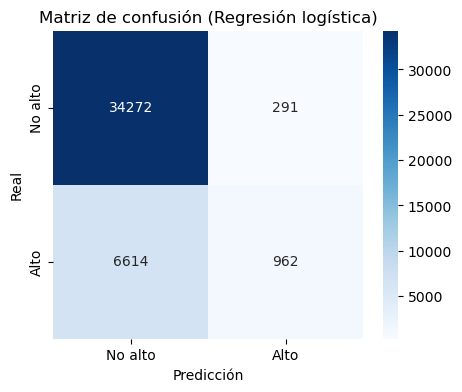

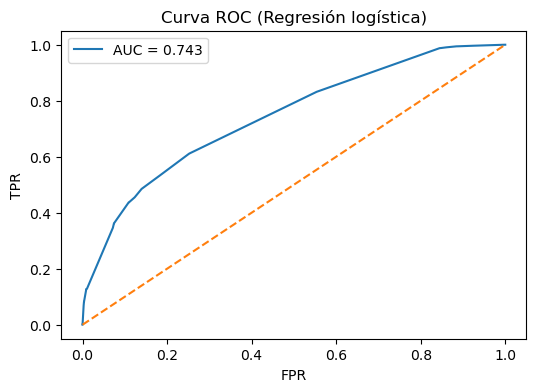

              precision    recall  f1-score   support

     No alto       0.84      0.99      0.91     34563
        Alto       0.77      0.13      0.22      7576

    accuracy                           0.84     42139
   macro avg       0.80      0.56      0.56     42139
weighted avg       0.83      0.84      0.78     42139



In [62]:
# Modelo base: Regresión logística
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Entrenar modelo base de regresión logística
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)

# Predicciones y métricas
y_pred_logreg = logreg.predict(X_test_scaled)
y_proba_logreg = logreg.predict_proba(X_test_scaled)[:, 1]

acc = accuracy_score(y_test, y_pred_logreg)
prec = precision_score(y_test, y_pred_logreg)
rec = recall_score(y_test, y_pred_logreg)
f1 = f1_score(y_test, y_pred_logreg)
roc_auc = roc_auc_score(y_test, y_proba_logreg)

print(f"Accuracy: {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall: {rec:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"ROC AUC: {roc_auc:.3f}")

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_logreg)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No alto','Alto'], yticklabels=['No alto','Alto'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de confusión (Regresión logística)')
plt.show()

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba_logreg)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('Curva ROC (Regresión logística)')
plt.legend()
plt.show()

# Reporte de clasificación
print(classification_report(y_test, y_pred_logreg, target_names=['No alto','Alto']))

## 10. Red neuronal (MLP)

Se define y entrena una red neuronal multicapa para la clasificacion binaria.

In [63]:
# Red neuronal multicapa (MLP) mejorada para clasificación binaria
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def construir_modelo(input_dim, capa_1=128, capa_2=64, capa_3=32, dropout_1=0.15, dropout_2=0.10, dropout_3=0.05, learning_rate=0.001):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.BatchNormalization(),
        layers.Dense(capa_1, activation=keras.layers.LeakyReLU(alpha=0.1)),
        layers.Dropout(dropout_1),
        layers.Dense(capa_2, activation=keras.layers.LeakyReLU(alpha=0.1)),
        layers.BatchNormalization(),
        layers.Dropout(dropout_2),
        layers.Dense(capa_3, activation=keras.layers.LeakyReLU(alpha=0.1)),
        layers.Dropout(dropout_3),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy", keras.metrics.AUC(name="auc")]
    )
    return model

input_dim = X_train_scaled.shape[1]
# Ejemplo de modelo (la búsqueda de hiperparámetros se realiza en la siguiente sección)
modelo_ejemplo = construir_modelo(input_dim=input_dim)
modelo_ejemplo.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 batch_normalization_4 (Bat  (None, 28)                112       
 chNormalization)                                                
                                                                 
 dense_17 (Dense)            (None, 192)               5568      
                                                                 
 dropout_12 (Dropout)        (None, 192)               0         
                                                                 
 dense_18 (Dense)            (None, 96)                18528     
                                                                 
 batch_normalization_5 (Bat  (None, 96)                384       
 chNormalization)                                                
                                                                 
 dropout_13 (Dropout)        (None, 96)               

## 11. Entrenamiento del modelo

Se entrena la red neuronal con early stopping para evitar sobreajuste. Los hiperparámetros pueden ajustarse según el contexto institucional (menos capas/neuronas que familia, regularización moderada).

In [69]:
# Grid search para encontrar el modelo más robusto posible (maximiza F1 en test, con recall y precisión balanceados)
from sklearn.model_selection import ParameterGrid
from tensorflow import keras
import numpy as np

# Grilla reducida: máximo ~100 combinaciones
param_grid = {
    'capa_1': [96, 128],           # 2 opciones
    'capa_2': [48],                # 1 opción (fijo)
    'capa_3': [24],                # 1 opción (fijo)
    'dropout_1': [0.10, 0.15],     # 2 opciones
    'dropout_2': [0.05],           # 1 opción (fijo)
    'dropout_3': [0.03],           # 1 opción (fijo)
    'learning_rate': [0.001, 0.0007], # 2 opciones
    'class_weight_1': [1.5, 2.0, 2.5], # 3 opciones
    'umbral': [0.35, 0.4],         # 2 opciones
    'batch_size': [128],           # 1 opción
    'epochs': [12]                 # 1 opción (ligeramente menos para acelerar)
}

mejor_f1 = 0
mejor_recall = 0
mejor_prec = 0
mejor_params = None
mejor_history = None
mejor_model = None
param_list = list(ParameterGrid(param_grid))
total = len(param_list)

for i, params in enumerate(param_list):
    print(f"Combinación {i+1}/{total}: {params}")
    # Construir modelo usando la función definida en la sección anterior
    model = construir_modelo(
        input_dim=X_train_scaled.shape[1],
        capa_1=params['capa_1'],
        capa_2=params['capa_2'],
        capa_3=params['capa_3'],
        dropout_1=params['dropout_1'],
        dropout_2=params['dropout_2'],
        dropout_3=params['dropout_3'],
        learning_rate=params['learning_rate']
    )

    # Early stopping
    early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True, verbose=0)

    # Class weights
    class_weight = {0: 1.0, 1: params['class_weight_1']}

    # Validación interna
    X_fit, X_val, y_fit, y_val = train_test_split(
        X_train_scaled, y_train, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train)

    # Entrenamiento
    history = model.fit(
        X_fit, y_fit,
        validation_data=(X_val, y_val),
        epochs=params['epochs'],
        batch_size=params['batch_size'],
        class_weight=class_weight,
        callbacks=[early_stop],
        verbose=0
    )

    # Evaluación en test
    y_pred_proba = model.predict(X_test_scaled).flatten()
    y_pred_bin = (y_pred_proba >= params['umbral']).astype(int)

    prec = precision_score(y_test, y_pred_bin)
    recall = recall_score(y_test, y_pred_bin)
    f1 = f1_score(y_test, y_pred_bin)

    # Guardar el mejor modelo según F1 (robustez general), y en caso de empate, el de mayor recall
    if f1 > mejor_f1 or (f1 == mejor_f1 and recall > mejor_recall):
        mejor_f1 = f1
        mejor_recall = recall
        mejor_prec = prec
        mejor_params = params.copy()
        mejor_history = history
        mejor_model = keras.models.clone_model(model)
        mejor_model.set_weights(model.get_weights())

print("Mejor F1 en test:", mejor_f1)
print("Recall en test:", mejor_recall)
print("Precisión en test:", mejor_prec)
print("Mejores hiperparámetros:")
print(mejor_params)

Combinación 1/48: {'batch_size': 128, 'capa_1': 96, 'capa_2': 48, 'capa_3': 24, 'class_weight_1': 1.5, 'dropout_1': 0.1, 'dropout_2': 0.05, 'dropout_3': 0.03, 'epochs': 12, 'learning_rate': 0.001, 'umbral': 0.35}
1317/1317 [==============================] - 2s 2ms/step
Combinación 2/48: {'batch_size': 128, 'capa_1': 96, 'capa_2': 48, 'capa_3': 24, 'class_weight_1': 1.5, 'dropout_1': 0.1, 'dropout_2': 0.05, 'dropout_3': 0.03, 'epochs': 12, 'learning_rate': 0.001, 'umbral': 0.4}
1317/1317 [==============================] - 3s 2ms/step
Combinación 3/48: {'batch_size': 128, 'capa_1': 96, 'capa_2': 48, 'capa_3': 24, 'class_weight_1': 1.5, 'dropout_1': 0.1, 'dropout_2': 0.05, 'dropout_3': 0.03, 'epochs': 12, 'learning_rate': 0.0007, 'umbral': 0.35}
1317/1317 [==============================] - 3s 2ms/step
Combinación 4/48: {'batch_size': 128, 'capa_1': 96, 'capa_2': 48, 'capa_3': 24, 'class_weight_1': 1.5, 'dropout_1': 0.1, 'dropout_2': 0.05, 'dropout_3': 0.03, 'epochs': 12, 'learning_rate': 

## 12. Evaluación del modelo

Se evalúa el desempeño de la red neuronal usando RMSE, MAE y R² en el conjunto de prueba. También se grafican la historia de entrenamiento y la relación predicción vs real.

1317/1317 [==============================] - 4s 3ms/step
Umbral de decisión óptimo: 0.35
Accuracy: 0.803
Precision: 0.453
Recall: 0.466
F1-score: 0.459
ROC AUC: 0.744


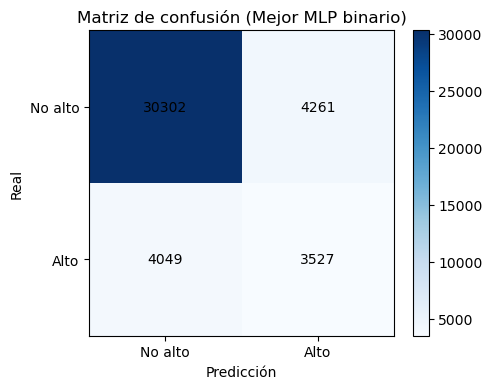

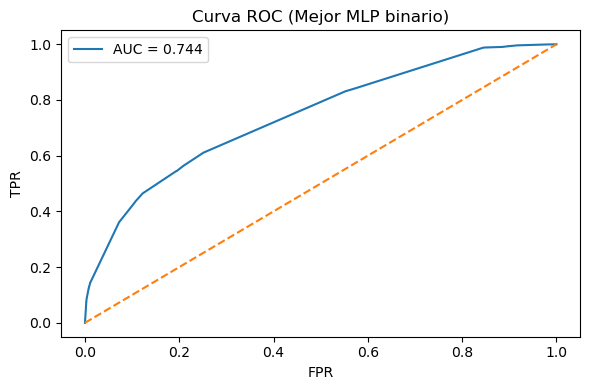

              precision    recall  f1-score   support

     No alto       0.88      0.88      0.88     34563
        Alto       0.45      0.47      0.46      7576

    accuracy                           0.80     42139
   macro avg       0.67      0.67      0.67     42139
weighted avg       0.80      0.80      0.80     42139



In [70]:
# Evaluación del mejor modelo MLP binario encontrado en el grid search
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
import matplotlib.pyplot as plt
import numpy as np

# Predicciones sobre el conjunto de prueba (probabilidades y clases) usando el mejor modelo
y_pred_proba = mejor_model.predict(X_test_scaled).flatten()

# Ajuste de umbral óptimo encontrado en el grid search
umbral = mejor_params['umbral']
y_pred_bin = (y_pred_proba >= umbral).astype(int)

# Métricas de clasificación binaria
acc = accuracy_score(y_test, y_pred_bin)
prec = precision_score(y_test, y_pred_bin)
rec = recall_score(y_test, y_pred_bin)
f1 = f1_score(y_test, y_pred_bin)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Umbral de decisión óptimo: {umbral}")
print(f"Accuracy: {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall: {rec:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"ROC AUC: {roc_auc:.3f}")

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_bin)
plt.figure(figsize=(5,4))
plt.imshow(cm, cmap='Blues')
plt.title('Matriz de confusión (Mejor MLP binario)')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.xticks([0,1], ['No alto','Alto'])
plt.yticks([0,1], ['No alto','Alto'])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')
plt.colorbar()
plt.tight_layout()
plt.show()

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('Curva ROC (Mejor MLP binario)')
plt.legend()
plt.tight_layout()
plt.show()

# Reporte de clasificación
print(classification_report(y_test, y_pred_bin, target_names=['No alto','Alto']))

## 13. Comparación de modelos

Se comparan los resultados del modelo base y la red neuronal.

In [71]:
# Comparación de modelos: Regresión logística vs Red neuronal (MLP binario)
import pandas as pd

resultados = pd.DataFrame([
    {
        "Modelo": "Regresión logística",
        "Accuracy": accuracy_score(y_test, y_pred_logreg),
        "Precision": precision_score(y_test, y_pred_logreg),
        "Recall": recall_score(y_test, y_pred_logreg),
        "F1": f1_score(y_test, y_pred_logreg),
        "ROC AUC": roc_auc_score(y_test, y_proba_logreg)
    },
    {
        "Modelo": "Red neuronal (MLP)",
        "Accuracy": accuracy_score(y_test, y_pred_bin),
        "Precision": precision_score(y_test, y_pred_bin),
        "Recall": recall_score(y_test, y_pred_bin),
        "F1": f1_score(y_test, y_pred_bin),
        "ROC AUC": roc_auc_score(y_test, y_pred_proba)
    }
])

display(resultados)

,Modelo,Accuracy,Precision,Recall,F1,ROC AUC
0,Regresión logística,0.836138,0.767757,0.126980,0.217918,0.742793
1,Red neuronal (MLP),0.802796,0.452876,0.465549,0.459125,0.743882


## 14. Registro de experimento con MLflow

Se registran parámetros, métricas y modelo en MLflow para trazabilidad y comparación de experimentos.

In [77]:
# Registro de experimento con MLflow para el mejor modelo encontrado en el grid search
if MLFLOW_AVAILABLE:
    try:
        # Levantar MLflow antes de ejecutar esta celda:
        # mlflow server --backend-store-uri sqlite:///mlflow.db --default-artifact-root ./mlruns --host 127.0.0.1 --port 5000
        mlflow.set_tracking_uri("http://localhost:5000")
        experiment = mlflow.set_experiment("Saber11_Atlantico_Clasificacion_colegio")

        X_train_np = X_train.to_numpy()
        X_test_np = X_test.to_numpy()

        tf.keras.utils.set_random_seed(RANDOM_STATE)

        with mlflow.start_run(
            experiment_id=experiment.experiment_id,
            run_name="modelo_clasificacion_isabella"
        ):
            mlflow.keras.autolog()

            # Log de hiperparámetros y configuración del mejor modelo
            mlflow.log_params(mejor_params)
            mlflow.log_param("numero_variables_encoded", X_train.shape[1])
            mlflow.log_param("patience", 4)  # Fijo según grid search
            mlflow.log_param("tracking_uri", "http://localhost:5000")

            # Log de métricas finales en test
            y_pred_proba = mejor_model.predict(X_test_scaled).flatten()
            y_pred_bin = (y_pred_proba >= mejor_params['umbral']).astype(int)
            mlflow.log_metric("accuracy", accuracy_score(y_test, y_pred_bin))
            mlflow.log_metric("precision", precision_score(y_test, y_pred_bin))
            mlflow.log_metric("recall", recall_score(y_test, y_pred_bin))
            mlflow.log_metric("f1", f1_score(y_test, y_pred_bin))
            mlflow.log_metric("roc_auc", roc_auc_score(y_test, y_pred_proba))

            # Log de historia de entrenamiento (loss, val_loss, etc.)
            for epoch_index in range(len(mejor_history.history.get("loss", []))):
                mlflow.log_metric("loss", mejor_history.history["loss"][epoch_index], step=epoch_index)
                if "accuracy" in mejor_history.history:
                    mlflow.log_metric("accuracy_epoch", mejor_history.history["accuracy"][epoch_index], step=epoch_index)
                if "auc" in mejor_history.history:
                    mlflow.log_metric("auc", mejor_history.history["auc"][epoch_index], step=epoch_index)
                if "val_loss" in mejor_history.history:
                    mlflow.log_metric("val_loss", mejor_history.history["val_loss"][epoch_index], step=epoch_index)
                if "val_accuracy" in mejor_history.history:
                    mlflow.log_metric("val_accuracy", mejor_history.history["val_accuracy"][epoch_index], step=epoch_index)
                if "val_auc" in mejor_history.history:
                    mlflow.log_metric("val_auc", mejor_history.history["val_auc"][epoch_index], step=epoch_index)

            mlflow.log_metric("final_loss", mejor_history.history["loss"][-1])
            if "val_loss" in mejor_history.history:
                mlflow.log_metric("final_val_loss", mejor_history.history["val_loss"][-1])
            if "accuracy" in mejor_history.history:
                mlflow.log_metric("final_accuracy", mejor_history.history["accuracy"][-1])
            if "auc" in mejor_history.history:
                mlflow.log_metric("final_auc", mejor_history.history["auc"][-1])
            if "val_accuracy" in mejor_history.history:
                mlflow.log_metric("final_val_accuracy", mejor_history.history["val_accuracy"][-1])
            if "val_auc" in mejor_history.history:
                mlflow.log_metric("final_val_auc", mejor_history.history["val_auc"][-1])

            mlflow.keras.log_model(mejor_model, "keras-model")

        print("Experimento registrado en MLflow usando http://localhost:5000.")
    except Exception as error:
        raise RuntimeError(
            "MLflow debe estar levantado en localhost:5000 para registrar el experimento. "
            "Ejecuta primero: mlflow server --backend-store-uri sqlite:///mlflow.db --default-artifact-root ./mlruns --host 127.0.0.1 --port 5000"
        ) from error
else:
    print("MLflow no está disponible en este ambiente.")

2026/05/23 14:26:33 WARNING mlflow.utils.autologging_utils: MLflow tensorflow autologging is known to be compatible with 2.16.2 <= tensorflow, but the installed version is 2.15.0. If you encounter errors during autologging, try upgrading / downgrading tensorflow to a compatible version, or try upgrading MLflow.


1317/1317 [==============================] - 3s 2ms/step


2026/05/23 14:26:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/23 14:26:41 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


INFO:tensorflow:Assets written to: C:\Users\ISABEL~1\AppData\Local\Temp\tmpws5k_vsx\model\data\model\assets


INFO:tensorflow:Assets written to: C:\Users\ISABEL~1\AppData\Local\Temp\tmpws5k_vsx\model\data\model\assets


🏃 View run modelo_clasificacion_isabella at: http://localhost:5000/#/experiments/2/runs/caf1efc41dad47b589e1e81b8dff0581
🧪 View experiment at: http://localhost:5000/#/experiments/2
Experimento registrado en MLflow usando http://localhost:5000.
